이 자료는 위키독스 딥 러닝을 이용한 자연어 처리 입문의 한국어 스팀 리뷰 감성 분석 튜토리얼입니다.  

링크 : https://wikidocs.net/94748

# 1. BiLSTM을 텍스트 분류에 사용하기

케라스에서는 양방향 LSTM을 사용하면서 return_sequences=False를 택할 경우에는 아래의 링크와 같이 동작합니다.  

https://wikidocs.net/images/page/94748/bilstm3.PNG

# 2. Colab에 kiwipiepy 설치

In [1]:
%pip install kiwipiepy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.5/35.5 MB 39.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.6/7.6 MB 24.7 MB/s eta 0:00:00
  Created wheel for kiwipiepy_model: filename=kiwipiepy_model-0.21.0-py3-none-any.whl size=35593192 sha256=a449d39cadfba7604fce5c841f63fd83d25695cb95b89e45553c145c7c6a6f3b
  Stored in directory: /root/.cache/pip/wheels/5f/94/81/3e8b1478625f1bdb3b72733dfe3086a8f77a8f25db2b1d746b
Successfully built kiwipiepy_model


# 3. 스팀 리뷰 데이터에 대한 이해와 전처리

| 라이브러리                        | 역할 요약               |
| ---------------------------- | ------------------- |
| `pandas`, `numpy`            | 데이터 불러오기 및 수학 연산    |
| `matplotlib`                 | 데이터 시각화             |
| `urllib.request`             | 인터넷에서 데이터 다운로드      |
| `Counter`                    | 단어 빈도수 세기           |
| `kiwipiepy`                  | 한국어 형태소 분석          |
| `train_test_split`           | 학습/검증용 데이터 분리       |
| `Tokenizer`, `pad_sequences` | 문장을 숫자로 변환하고 길이 맞추기 |


In [2]:
# 데이터 분석과 수치 계산에 자주 사용하는 라이브러리 불러오기
import pandas as pd        # 데이터 프레임(표 형태 데이터) 처리를 위한 라이브러리
import numpy as np         # 수학 계산(배열, 통계, 선형대수 등)에 사용하는 라이브러리

# 그래프(시각화) 관련 라이브러리
import matplotlib.pyplot as plt   # 데이터 시각화를 위한 라이브러리

# 웹에서 데이터를 불러오기 위한 모듈
import urllib.request       # 인터넷에서 파일이나 데이터를 다운로드할 때 사용

# 단어 등장 횟수 세기 위한 라이브러리
from collections import Counter   # 리스트나 문자열에서 요소의 개수를 쉽게 셀 수 있음

# 한국어 형태소 분석기 불러오기 (한국어 문장을 단어 단위로 나눔)
import kiwipiepy            # 한국어 형태소 분석 라이브러리 (Kiwi)

# 데이터를 훈련용(train)과 테스트용(test)으로 나누기 위한 함수
from sklearn.model_selection import train_test_split  # 머신러닝 학습용 데이터 분할 함수

# 텍스트 데이터를 숫자로 바꾸기 위한 도구
from tensorflow.keras.preprocessing.text import Tokenizer  # 단어를 숫자 인덱스로 변환
from tensorflow.keras.preprocessing.sequence import pad_sequences  # 문장의 길이를 맞춰줌 (패딩)

In [3]:
# 인터넷에 있는 파일(텍스트 데이터)을 내 컴퓨터(혹은 Colab 환경)로 다운로드하는 코드

import urllib.request  # 웹에서 데이터를 가져오기 위한 라이브러리

# urlretrieve(주소, 저장할 파일이름)
# 지정된 URL의 파일을 다운로드하여 현재 작업폴더에 "steam.txt" 이름으로 저장함
urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/bab2min/corpus/master/sentiment/steam.txt",  # 다운로드할 파일의 인터넷 주소
    filename="steam.txt"  # 저장할 파일 이름 (로컬에 저장될 이름)
)

('steam.txt', <http.client.HTTPMessage at 0x7cda5a1f5e80>)

In [4]:
# pandas 라이브러리를 이용해 'steam.txt' 파일을 불러오고, 데이터프레임(DataFrame) 형태로 저장
# 파일은 탭(\t)으로 구분되어 있으므로 read_table() 함수 사용
# names=['label', 'reviews'] → 첫 번째 열은 'label'(레이블, 감성값), 두 번째 열은 'reviews'(리뷰문장) 이름으로 지정
total_data = pd.read_table('steam.txt', names=['label', 'reviews'])

# 전체 데이터(리뷰)의 개수를 출력
print('전체 리뷰 개수 :', len(total_data))

전체 리뷰 개수 : 100000


In [5]:
total_data[:5]

,label,reviews
0,0,노래가 너무 적음
1,0,"돌겠네 진짜. 황숙아, 어크 공장 그만 돌려라. 죽는다."
2,1,막노동 체험판 막노동 하는사람인데 장비를 내가 사야돼 뭐지
3,1,차악!차악!!차악!!! 정말 이래서 왕국을 되찾을 수 있는거야??
4,1,시간 때우기에 좋음.. 도전과제는 50시간이면 다 깰 수 있어요


In [6]:
total_data['reviews'].nunique(), total_data['label'].nunique()

(99892, 2)

In [7]:
total_data.drop_duplicates(subset=['reviews'], inplace=True) # reviews 열에서 중복인 내용이 있다면 중복 제거
print('총 샘플의 수 :',len(total_data))

총 샘플의 수 : 99892


In [8]:
print(total_data.isnull().values.any())

False


In [9]:
# 전체 데이터를 학습용(train)과 테스트용(test)으로 나누는 코드

# train_test_split() : 데이터를 무작위로 섞은 뒤, 일부는 훈련용 / 일부는 테스트용으로 나눠줌
# test_size=0.25 → 전체 데이터의 25%를 테스트용으로 사용 (즉, 75%는 훈련용)
# random_state=42 → 무작위 분할 시 매번 같은 결과를 얻기 위해 시드(seed) 고정
train_data, test_data = train_test_split(total_data, test_size=0.25, random_state=42)

# 각각 데이터 개수를 확인
print('훈련용 리뷰의 개수 :', len(train_data))   # 학습(훈련)에 사용할 리뷰 수
print('테스트용 리뷰의 개수 :', len(test_data))   # 모델 평가(테스트)에 사용할 리뷰 수

훈련용 리뷰의 개수 : 74919
테스트용 리뷰의 개수 : 24973


<Axes: xlabel='label'>

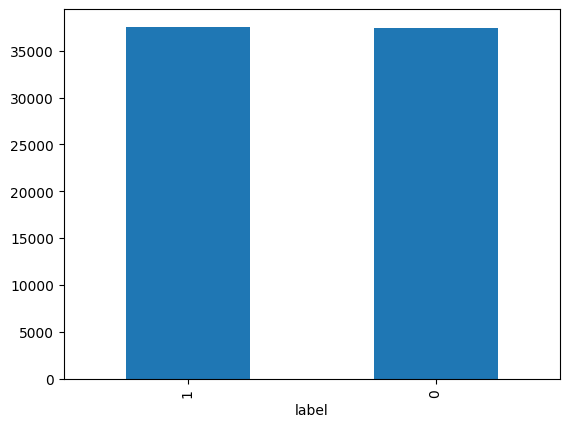

In [10]:
train_data['label'].value_counts().plot(kind = 'bar')

In [11]:
print(train_data.groupby('label').size().reset_index(name = 'count'))

   label  count
0      0  37376
1      1  37543


In [12]:
# 한글과 공백(띄어쓰기)을 제외한 모든 문자 제거하기
# 정규표현식 [^ㄱ-ㅎㅏ-ㅣ가-힣 ] → 한글 자모(ㄱ~ㅎ, ㅏ~ㅣ, 가~힣)와 공백만 남기고 나머지는 제거
train_data['reviews'] = train_data['reviews'].str.replace("[^ㄱ-ㅎㅏ-ㅣ가-힣 ]", "")

# 리뷰가 완전히 비어 있는 문자열("")이면 결측치(NaN)로 변경
# 즉, 텍스트가 모두 제거되어 내용이 없는 경우 NaN으로 표시
train_data['reviews'].replace('', np.nan, inplace=True)

# 결측치(누락된 데이터)가 있는지 확인
# 각 열(column)별로 NaN 개수를 출력
print(train_data.isnull().sum())

label      0
reviews    0
dtype: int64


/tmp/ipython-input-1569627610.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_data['reviews'].replace('', np.nan, inplace=True)


In [13]:
test_data.drop_duplicates(subset = ['reviews'], inplace=True) # 중복 제거
test_data['reviews'] = test_data['reviews'].str.replace("[^ㄱ-ㅎㅏ-ㅣ가-힣 ]","") # 정규 표현식 수행
test_data['reviews'].replace('', np.nan, inplace=True) # 공백은 Null 값으로 변경
test_data = test_data.dropna(how='any') # Null 값 제거
print('전처리 후 테스트용 샘플의 개수 :',len(test_data))

전처리 후 테스트용 샘플의 개수 : 24973


/tmp/ipython-input-2684537507.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test_data['reviews'].replace('', np.nan, inplace=True) # 공백은 Null 값으로 변경


In [14]:
stopwords = ['도', '는', '다', '의', '가', '이', '은', '한', '에', '하', '고', '을', '를', '인', '듯', '과', '와', '네', '들', '듯', '지', '임', '게', '만', '게임', '겜', '되', '음', '면']

In [15]:
from kiwipiepy import Kiwi

# Kiwi 형태소 분석기 객체 생성
kiwi = Kiwi()

# 1️⃣ 학습 데이터 토큰화 (형태소 분석)
train_data['tokenized'] = train_data['reviews'].apply(lambda x: [token.form for token in kiwi.tokenize(x)])

# 불용어(stopwords)에 포함되지 않은 단어만 남기기
train_data['tokenized'] = train_data['tokenized'].apply(lambda x: [word for word in x if word not in stopwords])

# 2️⃣ 테스트 데이터 토큰화 (형태소 분석)
test_data['tokenized'] = test_data['reviews'].apply(lambda x: [token.form for token in kiwi.tokenize(x)])

# 불용어 제거
test_data['tokenized'] = test_data['tokenized'].apply(lambda x: [word for word in x if word not in stopwords])

In [16]:
# 부정(0) 리뷰의 토큰(단어)만 모두 모으기
# np.hstack() : 여러 리스트를 하나로 이어붙여 1차원 배열로 만듦
negative_words = np.hstack(train_data[train_data.label == 0]['tokenized'].values)

# 긍정(1) 리뷰의 토큰(단어)만 모두 모으기
positive_words = np.hstack(train_data[train_data.label == 1]['tokenized'].values)

In [17]:
negative_word_count = Counter(negative_words)
print(negative_word_count.most_common(20))

[(np.str_('.'), 19474), (np.str_('ᆫ'), 18570), (np.str_('어'), 15931), (np.str_('었'), 13292), (np.str_('ᆷ'), 11356), (np.str_('ᆯ'), 10930), (np.str_('안'), 8159), (np.str_('어서'), 7631), (np.str_('것'), 7305), (np.str_('없'), 7162), (np.str_('거'), 7024), (np.str_('나'), 6424), (np.str_('는데'), 5758), (np.str_('있'), 5732), (np.str_('...'), 5211), (np.str_('사'), 5127), (np.str_('보'), 5051), (np.str_('ᆸ니다'), 4280), (np.str_('같'), 4263), (np.str_('기'), 4251)]


In [18]:
positive_word_count = Counter(positive_words)
print(positive_word_count.most_common(20))

[(np.str_('.'), 23660), (np.str_('ᆫ'), 19599), (np.str_('어'), 15326), (np.str_('었'), 12675), (np.str_('ᆯ'), 12181), (np.str_('있'), 9957), (np.str_('ᆷ'), 7452), (np.str_('것'), 6894), (np.str_('ᆸ니다'), 6661), (np.str_('어서'), 6505), (np.str_('보'), 6451), (np.str_('좋'), 5839), (np.str_('습니다'), 5180), (np.str_('기'), 4988), (np.str_('재밌'), 4982), (np.str_('나'), 4977), (np.str_('거'), 4949), (np.str_(','), 4903), (np.str_('지만'), 4549), (np.str_('없'), 4160)]


긍정 리뷰의 평균 길이 : 17.973497056708307
부정 리뷰의 평균 길이 : 18.40582191780822


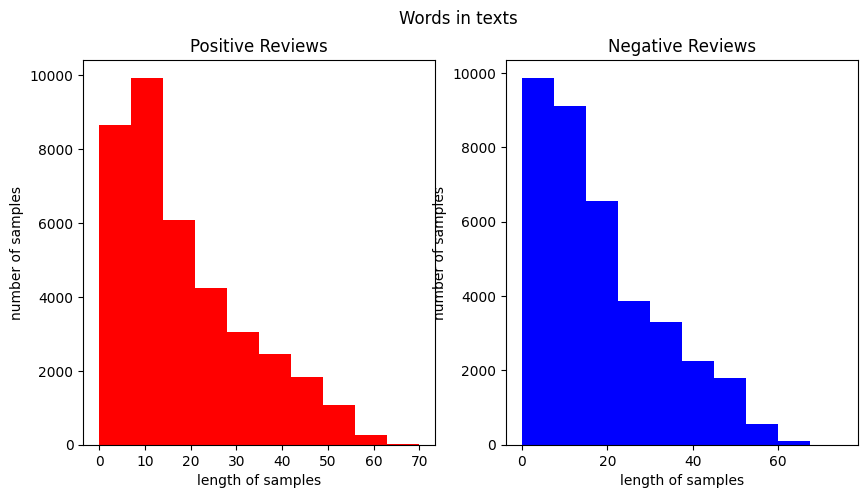

In [19]:
fig,(ax1,ax2) = plt.subplots(1,2,figsize=(10,5))
text_len = train_data[train_data['label']==1]['tokenized'].map(lambda x: len(x))
ax1.hist(text_len, color='red')
ax1.set_title('Positive Reviews')
ax1.set_xlabel('length of samples')
ax1.set_ylabel('number of samples')
print('긍정 리뷰의 평균 길이 :', np.mean(text_len))

text_len = train_data[train_data['label']==0]['tokenized'].map(lambda x: len(x))
ax2.hist(text_len, color='blue')
ax2.set_title('Negative Reviews')
fig.suptitle('Words in texts')
ax2.set_xlabel('length of samples')
ax2.set_ylabel('number of samples')
print('부정 리뷰의 평균 길이 :', np.mean(text_len))
plt.show()

In [20]:
# 학습(훈련) 데이터의 입력 부분 (리뷰 내용)
# 'tokenized' 열에는 형태소 분석된 단어 리스트가 들어 있음
X_train = train_data['tokenized'].values

# 학습(훈련) 데이터의 정답(label) 부분
# 0 = 부정 리뷰, 1 = 긍정 리뷰
y_train = train_data['label'].values

# 테스트(평가) 데이터의 입력 부분
X_test = test_data['tokenized'].values

# 테스트(평가) 데이터의 정답(label) 부분
y_test = test_data['label'].values

In [21]:
# 단어를 숫자로 바꿔주는 도구(Tokenize)를 만듭니다.
# Keras의 Tokenizer는 단어별로 고유한 정수 번호(ID)를 자동으로 부여합니다.
tokenizer = Tokenizer()

# 학습용 문장들(X_train)에 나오는 모든 단어를 분석하여
# 단어 사전(vocabulary)을 생성하고 각 단어에 번호를 매깁니다.
tokenizer.fit_on_texts(X_train)

In [22]:
threshold = 2
total_cnt = len(tokenizer.word_index) # 단어의 수
rare_cnt = 0 # 등장 빈도수가 threshold보다 작은 단어의 개수를 카운트
total_freq = 0 # 훈련 데이터의 전체 단어 빈도수 총 합
rare_freq = 0 # 등장 빈도수가 threshold보다 작은 단어의 등장 빈도수의 총 합

# 단어와 빈도수의 쌍(pair)을 key와 value로 받는다.
for key, value in tokenizer.word_counts.items():
    total_freq = total_freq + value

    # 단어의 등장 빈도수가 threshold보다 작으면
    if(value < threshold):
        rare_cnt = rare_cnt + 1
        rare_freq = rare_freq + value

print('단어 집합(vocabulary)의 크기 :',total_cnt)
print('등장 빈도가 %s번 이하인 희귀 단어의 수: %s'%(threshold - 1, rare_cnt))
print("단어 집합에서 희귀 단어의 비율:", (rare_cnt / total_cnt)*100)
print("전체 등장 빈도에서 희귀 단어 등장 빈도 비율:", (rare_freq / total_freq)*100)

단어 집합(vocabulary)의 크기 : 38930
등장 빈도가 1번 이하인 희귀 단어의 수: 20692
단어 집합에서 희귀 단어의 비율: 53.1518109427177
전체 등장 빈도에서 희귀 단어 등장 빈도 비율: 1.518439292148395


In [23]:
# 전체 단어 개수 중 빈도수 2이하인 단어 개수는 제거.
# 0번 패딩 토큰과 1번 OOV 토큰을 고려하여 +2
vocab_size = total_cnt - rare_cnt + 2
print('단어 집합의 크기 :',vocab_size)

단어 집합의 크기 : 18240


In [24]:
tokenizer = Tokenizer(vocab_size, oov_token = 'OOV')
tokenizer.fit_on_texts(X_train)
X_train = tokenizer.texts_to_sequences(X_train)
X_test = tokenizer.texts_to_sequences(X_test)

In [25]:
print(X_train[:3])

[[340, 6, 48, 88, 159, 589, 270, 35, 22, 81, 64, 54, 3, 124, 16, 56, 16], [74, 142, 306, 29, 5, 72, 450, 645, 535, 9, 21, 5, 93], [4867, 1299, 15]]


In [26]:
print(X_test[:3])

[[792, 1326, 14, 426, 16, 2, 113, 52, 17, 2362, 5, 487], [4757, 702, 427, 775, 692, 150, 15, 1643, 106, 345, 248, 6, 86, 3, 9, 7, 583, 594, 5091, 269, 186, 3803, 6, 48, 88, 445, 9, 5727, 5130], [868, 68, 33, 2, 395]]


리뷰의 최대 길이 : 75
리뷰의 평균 길이 : 18.18917764519014


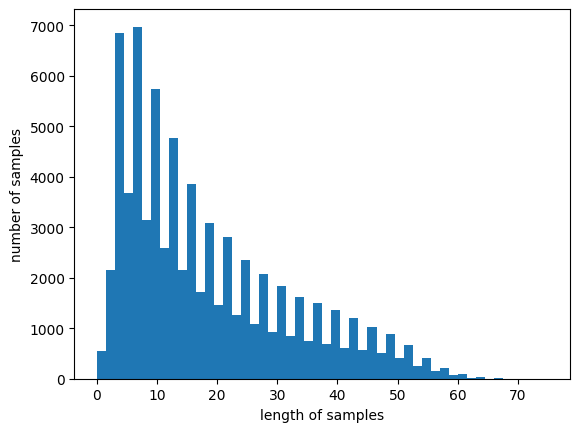

In [27]:
print('리뷰의 최대 길이 :',max(len(l) for l in X_train))
print('리뷰의 평균 길이 :',sum(map(len, X_train))/len(X_train))
plt.hist([len(s) for s in X_train], bins=50)
plt.xlabel('length of samples')
plt.ylabel('number of samples')
plt.show()

In [28]:
def below_threshold_len(max_len, nested_list):
  cnt = 0
  for s in nested_list:
    if(len(s) <= max_len):
        cnt = cnt + 1
  print('전체 샘플 중 길이가 %s 이하인 샘플의 비율: %s'%(max_len, (cnt / len(nested_list))*100))

In [29]:
max_len = 60
below_threshold_len(max_len, X_train)

전체 샘플 중 길이가 60 이하인 샘플의 비율: 99.86518773608832


In [30]:
X_train = pad_sequences(X_train, maxlen = max_len)
X_test = pad_sequences(X_test, maxlen = max_len)

# 4. BiLSTM으로 스팀 리뷰 감성 분류하기

| 코드 요소             | 설명                                                 |
| ----------------- | -------------------------------------------------- |
| `re`              | 정규 표현식(Regular Expression) 처리용 모듈 — 텍스트 전처리에 자주 사용 |
| `Embedding`       | 단어를 고정 길이 벡터로 바꿔주는 층 (Word2Vec과 유사 기능)             |
| `Dense`           | 완전연결층 (Fully Connected Layer), 분류기의 마지막 부분에 주로 사용  |
| `GRU`             | 순환신경망(RNN)의 변형, 계산량이 적고 빠름                         |
| `LSTM`            | 장단기 메모리(Long Short-Term Memory), 긴 문맥을 잘 기억하는 RNN  |
| `Bidirectional`   | 양방향 RNN — 앞뒤 문맥을 모두 반영                             |
| `Sequential`      | Keras에서 층을 순차적으로 쌓는 간단한 모델 구조                      |
| `load_model`      | 이미 학습한 모델 파일을 불러올 때 사용                             |
| `EarlyStopping`   | 성능이 더 이상 개선되지 않으면 학습을 자동으로 멈춤                      |
| `ModelCheckpoint` | 학습 중 가장 성능이 좋은 모델을 자동으로 저장                         |


In [31]:
# 정규 표현식(Regular Expression) 사용을 위한 모듈
# 텍스트에서 특정 패턴(예: 특수문자, 숫자 등)을 찾아 제거하거나 변환할 때 사용
import re

# 딥러닝 모델을 구성하기 위한 Keras의 여러 층(Layer) 불러오기
from tensorflow.keras.layers import Embedding, Dense, GRU, LSTM, Bidirectional

# Sequential : 층(layer)을 차례대로 쌓아 올리는 가장 기본적인 신경망 모델
# load_model : 저장된 모델(.h5 파일 등)을 다시 불러올 때 사용
from tensorflow.keras.models import Sequential, load_model

# 모델 학습 도중 조기 종료 및 최적 모델 저장을 위한 도구
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

| 층 종류                   | 설명              | 주요 역할         |
| ---------------------- | --------------- | ------------- |
| **Embedding**          | 단어를 숫자 → 벡터로 변환 | 입력층 역할        |
| **Bidirectional(GRU)** | 문맥을 양방향으로 학습    | 문장 이해         |
| **Dense(1, sigmoid)**  | 0~1 확률 출력       | 감성 분류 (이진 분류) |


In [32]:
# Sequential() : 층(layer)을 순서대로 쌓는 방식의 기본 신경망 모델
model = Sequential()

# ① Embedding 층
# 단어를 고정된 길이의 실수 벡터로 변환
# vocab_size : 전체 단어 수 (사전 크기)
# 100 : 각 단어를 100차원 벡터로 표현
model.add(Embedding(vocab_size, 100))

# ② Bidirectional GRU 층
# GRU : 순환신경망(RNN)의 한 종류로, 문장의 순서를 고려하며 학습
# Bidirectional : 앞에서 뒤로, 뒤에서 앞으로 두 방향 모두 문맥을 학습
# 100 : GRU 유닛(노드)의 개수
model.add(Bidirectional(GRU(100)))

# ③ Dense 층 (출력층)
# 출력 노드 1개 → 감성(긍정/부정) 예측
# sigmoid : 0~1 사이 확률값 출력 (0=부정, 1=긍정)
model.add(Dense(1, activation='sigmoid'))

In [33]:
es = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=4)
mc = ModelCheckpoint('best_model.h5', monitor='val_acc', mode='max', verbose=1, save_best_only=True)

In [34]:
model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['acc'])
history = model.fit(X_train, y_train, epochs=15, callbacks=[es, mc], batch_size=256, validation_split=0.2)

Epoch 1/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - acc: 0.6168 - loss: 0.6421
Epoch 1: val_acc improved from -inf to 0.72157, saving model to best_model.h5


235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - acc: 0.6171 - loss: 0.6419 - val_acc: 0.7216 - val_loss: 0.5465
Epoch 2/15
231/235 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - acc: 0.7586 - loss: 0.5009
Epoch 2: val_acc improved from 0.72157 to 0.74806, saving model to best_model.h5


235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - acc: 0.7588 - loss: 0.5007 - val_acc: 0.7481 - val_loss: 0.5108
Epoch 3/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - acc: 0.7924 - loss: 0.4506
Epoch 3: val_acc improved from 0.74806 to 0.77376, saving model to best_model.h5


235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - acc: 0.7924 - loss: 0.4506 - val_acc: 0.7738 - val_loss: 0.4800
Epoch 4/15
233/235 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - acc: 0.8090 - loss: 0.4263
Epoch 4: val_acc improved from 0.77376 to 0.78050, saving model to best_model.h5


235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - acc: 0.8089 - loss: 0.4263 - val_acc: 0.7805 - val_loss: 0.4838
Epoch 5/15
233/235 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - acc: 0.8136 - loss: 0.4138
Epoch 5: val_acc did not improve from 0.78050
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - acc: 0.8136 - loss: 0.4138 - val_acc: 0.7775 - val_loss: 0.4689
Epoch 6/15
234/235 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - acc: 0.8270 - loss: 0.3947
Epoch 6: val_acc improved from 0.78050 to 0.78744, saving model to best_model.h5


235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - acc: 0.8270 - loss: 0.3947 - val_acc: 0.7874 - val_loss: 0.4565
Epoch 7/15
232/235 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - acc: 0.8364 - loss: 0.3771
Epoch 7: val_acc did not improve from 0.78744
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - acc: 0.8363 - loss: 0.3772 - val_acc: 0.7805 - val_loss: 0.4968
Epoch 8/15
233/235 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - acc: 0.8435 - loss: 0.3660
Epoch 8: val_acc did not improve from 0.78744
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - acc: 0.8435 - loss: 0.3661 - val_acc: 0.7838 - val_loss: 0.4727
Epoch 9/15
233/235 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - acc: 0.8505 - loss: 0.3533
Epoch 9: val_acc did not improve from 0.78744
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - acc: 0.8504 - loss: 0.3533 - val_acc: 0.7828 - val_loss: 0.4763
Epoch 10/15
233/235 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - acc: 0.8578 - loss: 0.3377
Epoch 10: val_acc did not improve from 0.78744
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - acc: 0.857

In [35]:
loaded_model = load_model('best_model.h5')
print("테스트 정확도: %.4f" % (loaded_model.evaluate(X_test, y_test)[1]))

781/781 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - acc: 0.7829 - loss: 0.4618
테스트 정확도: 0.7865


# 5. 리뷰 예측해보기

In [36]:
import re
from kiwipiepy import Kiwi

# Kiwi 형태소 분석기 객체 생성
kiwi = Kiwi()

# 새 문장의 감성(긍정/부정)을 예측하는 함수 정의
def sentiment_predict(new_sentence):
    # ① 한글과 공백을 제외한 모든 문자 제거 (영어, 숫자, 특수문자 삭제)
    new_sentence = re.sub(r'[^ㄱ-ㅎㅏ-ㅣ가-힣 ]','', new_sentence)

    # ② 형태소 분석(토큰화)
    # kiwi.tokenize()는 형태소 단위로 문장을 나누어줌
    # token.form은 형태소의 실제 단어(표면형)를 의미
    new_sentence = [token.form for token in kiwi.tokenize(new_sentence)]

    # ③ 불용어 제거 (예: "이", "가", "은", "는" 등)
    new_sentence = [word for word in new_sentence if not word in stopwords]

    # ④ 정수 인코딩 (단어를 숫자 시퀀스로 변환)
    encoded = tokenizer.texts_to_sequences([new_sentence])

    # ⑤ 패딩(Padding) : 입력 문장의 길이를 모델 입력 크기(max_len)에 맞게 조정
    pad_new = pad_sequences(encoded, maxlen=max_len)

    # ⑥ 학습된 모델로 예측 수행 (긍정 확률 계산)
    score = float(loaded_model.predict(pad_new))

    # ⑦ 결과 출력
    if(score > 0.5):
        print("{:.2f}% 확률로 긍정 리뷰입니다.".format(score * 100))
    else:
        print("{:.2f}% 확률로 부정 리뷰입니다.".format((1 - score) * 100))

In [37]:
sentiment_predict('노잼 ..완전 재미 없음 ㅉㅉ')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
90.01% 확률로 부정 리뷰입니다.


/tmp/ipython-input-2341261756.py:27: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  score = float(loaded_model.predict(pad_new))


In [38]:
sentiment_predict('유일하게 어벤져스 시리즈중에 엔딩 안본 게임이다. 돈버린 느낌')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
64.11% 확률로 긍정 리뷰입니다.


/tmp/ipython-input-2341261756.py:27: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  score = float(loaded_model.predict(pad_new))


In [39]:
sentiment_predict('조금 어렵지만 재밌음ㅋㅋ')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
97.47% 확률로 긍정 리뷰입니다.


/tmp/ipython-input-2341261756.py:27: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  score = float(loaded_model.predict(pad_new))


In [40]:
sentiment_predict('케릭터가 예뻐서 좋아요')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
92.80% 확률로 긍정 리뷰입니다.


/tmp/ipython-input-2341261756.py:27: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  score = float(loaded_model.predict(pad_new))
